Домашнее задание №18. Кручинин С.В.
Задача. Класс prosrochka, 1 или 0. Метод KNN.
Запускать из папки дз18.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('priznaki.csv')
df = df[df['na_rukah'] == 0].copy()
print('сдач', len(df), 'просрочек', int(df['prosrochka'].sum()))
cols = ['vozrast', 'tema_sovpala', 'zhanr_sovpal', 'srok_dney', 'skok_brali']
X = df[cols]
y = df['prosrochka'].astype(int)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)
scaler = StandardScaler()
Xtr = scaler.fit_transform(Xtr)
Xte = scaler.transform(Xte)
print('тест', len(yte), 'просрочек на тесте', int(yte.sum()))
for k in (3, 5, 7):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(Xtr, ytr)
    proba = knn.predict_proba(Xte)[:, 1]
    print('k', k, 'AUC', round(roc_auc_score(yte, proba), 3))


сдач 81 просрочек 12
тест 27 просрочек на тесте 4
k 3 AUC 0.804
k 5 AUC 0.674
k 7 AUC 0.592


Решение. Беру k = 3, у него AUC выше. Ниже порог 0.3 и порог 0.5.


порог 0.5
accuracy 0.815 precision 0.333 recall 0.25 F1 0.286
матрица [[21, 2], [3, 1]]
порог 0.3
accuracy 0.667 precision 0.308 recall 1.0 F1 0.471
матрица [[14, 9], [0, 4]]


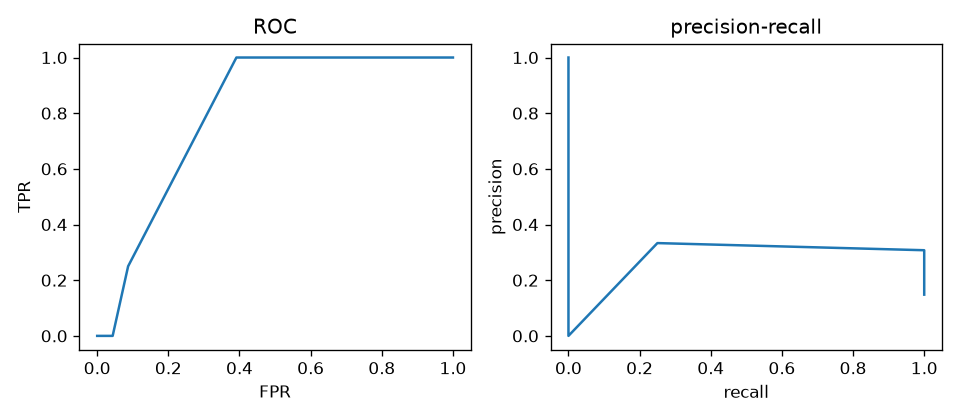

In [2]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(Xtr, ytr)
proba = knn.predict_proba(Xte)[:, 1]
for t in (0.5, 0.3):
    pred = (proba >= t).astype(int)
    print('порог', t)
    print('accuracy', round(accuracy_score(yte, pred), 3),
          'precision', round(precision_score(yte, pred, zero_division=0), 3),
          'recall', round(recall_score(yte, pred, zero_division=0), 3),
          'F1', round(f1_score(yte, pred, zero_division=0), 3))
    print('матрица', confusion_matrix(yte, pred).tolist())
fpr, tpr, _ = roc_curve(yte, proba)
prec, rec, _ = precision_recall_curve(yte, proba)
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].plot(fpr, tpr)
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC')
axes[1].plot(rec, prec)
axes[1].set_xlabel('recall')
axes[1].set_ylabel('precision')
axes[1].set_title('precision-recall')
plt.show()


Ответ. k = 3, порог 0.3: все 4 просрочки на тесте пойманы, ложных тревог 9. Порог 0.5 слишком много должников пропускает.
